In [1]:
import os
import sys
import torch
import numpy as np
import scipy.io
import h5py
import argparse
from random import SystemRandom

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.distributions.normal import Normal
from torch.distributions import kl_divergence

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

from lib.utils import *
from lib.functions import DeepONet1, GRU_unit, Decoder
from lib.ProposeModel import *
from lib.BaselineModel import *
from torch.multiprocessing import Pool

matplotlib.font_manager.fontManager.addfont('lib/fonts/times.ttf')

# set random seed
seed_value = 0
np.random.seed(seed_value)
random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value) 
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False 

In [2]:
experimentID = 700
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("experiments/experiment_" + str(experimentID) + '.ckpt')
args = checkpoint['args']

def read_data():
    reader = MatReader("data/dataset/data_" + args.data_version + ".mat")
    Xs = reader.read_field('Xs').permute(0,2,1)
    ts = reader.read_field('ts').repeat(Xs.shape[0],1)
    xs = reader.read_field('xs')[0]
    try:
        us = reader.read_field('us')
    except:
        us = torch.zeros((Xs.shape[0],Xs.shape[2])) 
    noise = (torch.tensor(np.random.sample(Xs.shape)).float() - 0.5) * 2.0
    #noise = torch.tensor(np.random.randn(*Xs.shape)).float()
    Xs_noise = Xs + args.noise_weight * noise
    
    n = 5000
    T = 100
    s_GT = Xs[:n,:T,:]
    s = Xs_noise[:n,:T,:]
    us = us[:n]
    ts = ts[:n,:T]
    
    observed_points = int(T*args.obs_ratio)
    s_mask = torch.zeros(n, observed_points, len(xs))
    t_mask = torch.zeros(n, observed_points)
    s_GT_mask = torch.zeros(n, observed_points, len(xs))
    mask = np.zeros((n, T), dtype=int)
    for i in range(n):
        observed_indices = np.random.choice(np.arange(1,T), observed_points-1, replace=False)
        sorted_indices = np.sort(observed_indices)
        mask[i, 0] = 1
        mask[i, observed_indices] = 1
        s_mask[i,0] = s[i,0]
        s_mask[i,1:] = s[i,sorted_indices]
        s_GT_mask[i,0] = s_GT[i,0]
        s_GT_mask[i,1:] = s_GT[i,sorted_indices]
        t_mask[i,0] = ts[i,0]
        t_mask[i,1:] = ts[i,sorted_indices]
    mask = torch.tensor(mask)
    
    Ntr = int(n * 0.99)
    
    s_data_tr = s_mask[:Ntr]; t_data_tr = t_mask[:Ntr]; u_data_tr = us[:Ntr] 
    s_data_te = s_mask[Ntr:]; t_data_te = t_mask[Ntr:]; u_data_te = us[Ntr:] 
    test_GT_mask = s_GT_mask[Ntr:]; test_GT = s_GT[Ntr:]; test_noise = s[Ntr:]

    print("s.shape:", s.shape)
    print("s_data_tr.shape:", s_data_tr.shape)
    print("t_data_tr.shape:", t_data_tr.shape)
    print("u_data_tr.shape:", u_data_tr.shape)
    print("Ntr:", Ntr)
    
    return(Ntr, s_data_te, t_data_te, u_data_te, xs, ts, mask, test_GT_mask, test_GT, test_noise)

Ntr, s_data_te, t_data_te, u_data_te, xs, ts, mask, test_GT_mask, test_GT, test_noise = read_data()
args.input_dim = len(xs)


s.shape: torch.Size([5000, 100, 64])
s_data_tr.shape: torch.Size([4950, 60, 64])
t_data_tr.shape: torch.Size([4950, 60])
u_data_tr.shape: torch.Size([4950, 64])
Ntr: 4950


###############################################
700error: tensor(0.7370)
700error_mask: tensor(0.7082)
error: tensor(0.7370) +- tensor(2.0934)


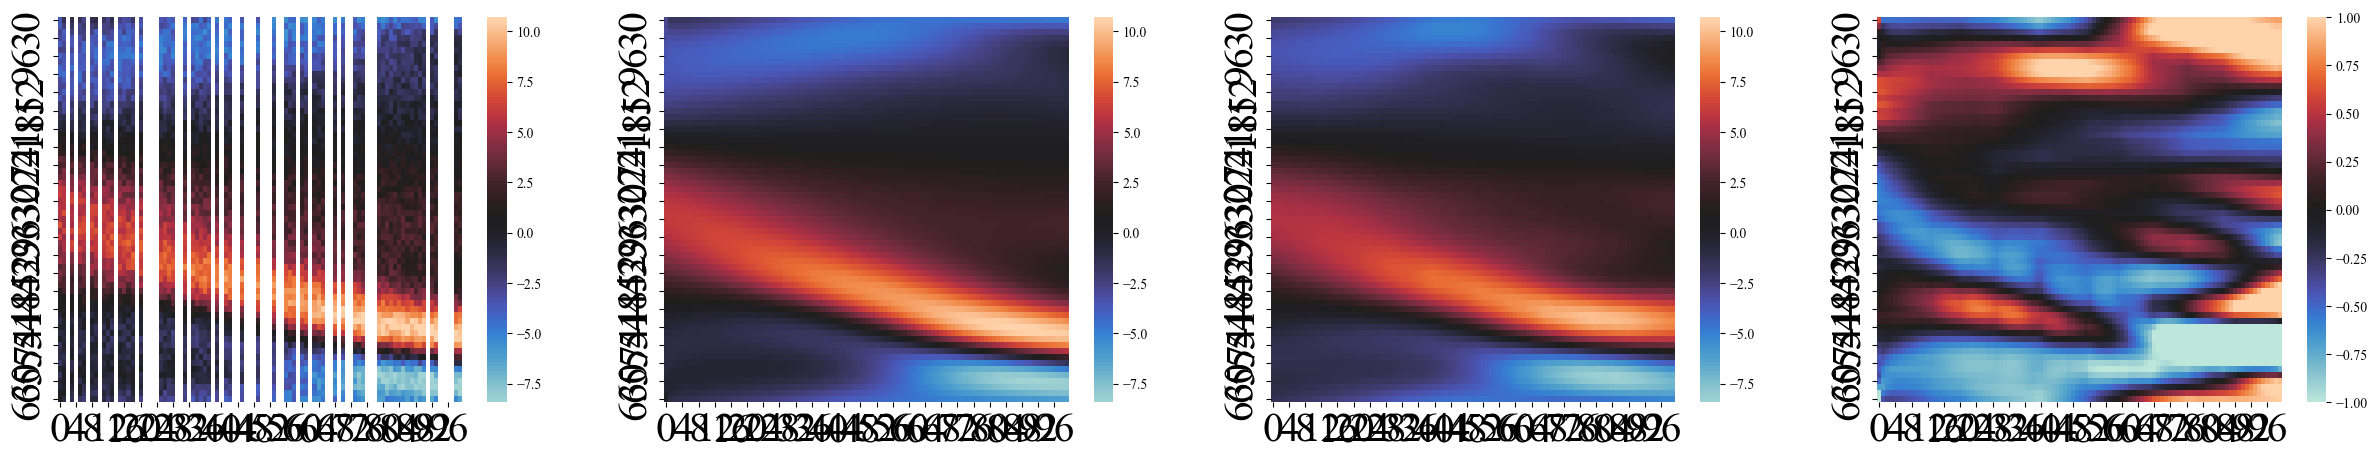

In [5]:
#expIDs = [700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711]
expIDs = [700]

for ei in range(len(expIDs)):
    experimentID = expIDs[ei]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load("experiments/experiment_" + str(experimentID) + '.ckpt')
    args = checkpoint['args']
    
    if experimentID == 700:
        model = RLNO(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 701:
        model = DeepONet(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 702:
        model = GRUVAE(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 703:
        model = GRUDecay(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 704:
        model = MLAE_LD(args, device)
        model.load_state_dict(checkpoint['state_dict'])   
    elif experimentID == 705:
        model = LNODE(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 706:
        model = Base_PDENET(args, device, xs)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 707:
        model = RLNO_MI(args, device, u_data_te.shape[-1])
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 708:
        model = MIONet(args, device, u_data_te.shape[-1])
        model.load_state_dict(checkpoint['state_dict'])        
    elif experimentID == 709:
        model = LNO_Ab1(args, device)
        model.load_state_dict(checkpoint['state_dict'])     
    elif experimentID == 710:
        model = LNO_Ab2(args, device)
        model.load_state_dict(checkpoint['state_dict']) 
    elif experimentID == 711:
        model = LNO_Ab3(args, device)
        model.load_state_dict(checkpoint['state_dict']) 
        
    ## testing
    batch_mask = [s_data_te.to(device), t_data_te.to(device), u_data_te.to(device)]
    pred_y_mask = model.test(batch_mask).cpu()
    if experimentID in [700,709,710,711]:
        batch = [s_data_te.to(device), t_data_te.to(device), u_data_te.to(device)]
        pred_y = model.test_full(batch, ts[Ntr:].to(device)).cpu()
    else:
        batch = [test_noise.to(device), ts[Ntr:].to(device), u_data_te.to(device)]
        pred_y = model.test(batch).cpu()
    
    index = 6
    s = test_noise[index].t().cpu()
    s_GT = test_GT[index].t().cpu()
    s_mask = s * mask[index].unsqueeze(-1).repeat(1,len(xs)).t()
    print("###############################################")
    if len(pred_y.shape) == 4:
        error = torch.mean((torch.mean(pred_y,axis=0)-test_GT)**2, (1,2))
        print(str(experimentID) + "error:", torch.mean((torch.mean(pred_y,axis=0)-test_GT)**2))
        #print("error_before:", torch.mean((torch.mean(pred_y,axis=0)-test_GT)[:args.rec_len]**2))
        #print("error_later:", torch.mean((torch.mean(pred_y,axis=0)-test_GT)[args.rec_len:]**2))
        print(str(experimentID) + "error_mask:", torch.mean((torch.mean(pred_y_mask,axis=0)-test_GT_mask)**2))
        sp = pred_y[0,index].t().cpu().detach().numpy()
    else:
        error = torch.mean((pred_y-test_GT)**2, (1,2))
        print(str(experimentID) + "error:", torch.mean((pred_y-test_GT)**2))
        #print("error_before:", torch.mean((pred_y-test_GT)[:args.rec_len]**2))
        #print("error_later:", torch.mean((pred_y-test_GT)[args.rec_len:]**2))
        print(str(experimentID) + "error_mask:", torch.mean((pred_y_mask-test_GT_mask)**2))
        sp = pred_y[index].t().cpu().detach().numpy()
    print("error:",torch.mean(error), "+-", torch.std(error)*2)
    
    fig = plt.figure(figsize=(30,5))
    ms = 10; ls = 30
    font1 = {'family':'Times New Roman', 'weight':'normal','size':ls}
    plt.rcParams['font.family'] = 'Times New Roman'
    #cmap='viridis'
    
    ax0 = fig.add_subplot(1,4,1)
    data = pd.DataFrame(s_mask)
    data.replace(0, np.nan, inplace=True)
    s_max = s_GT.max(); s_min = s_GT.min()
    #s_max = 0.6; s_min = -1.6
    cmap = sns.heatmap(data, center=s.mean(), vmax=s_max, vmin=s_min)
    plt.tick_params(labelsize=ls)

    ax1 = fig.add_subplot(1,4,2)
    data = pd.DataFrame(s_GT)
    cmap = sns.heatmap(data, center=s.mean(), vmax=s_max, vmin=s_min)
    plt.tick_params(labelsize=ls)

    ax2 = fig.add_subplot(1,4,3)
    data = pd.DataFrame(sp)
    cmap = sns.heatmap(data, center=s.mean(), vmax=s_max, vmin=s_min)
    plt.tick_params(labelsize=ls)
    
    ax3 = fig.add_subplot(1,4,4)
    data = pd.DataFrame(sp-s_GT.numpy())
    cmap = sns.heatmap(data, center=0, vmax=1, vmin=-1)
    plt.tick_params(labelsize=ls)
    
    plt.savefig("results/{}.pdf".format(experimentID))   
    

In [5]:
reader = MatReader("data/dataset/data_ks.mat")
Xs = reader.read_field('Xs')
print(Xs.shape)


torch.Size([20000, 64, 100])


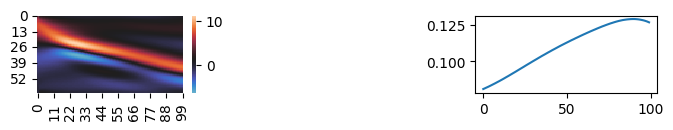

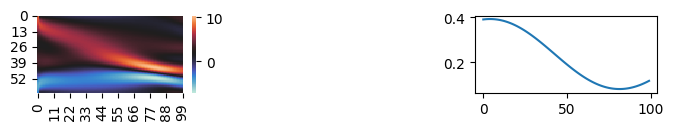

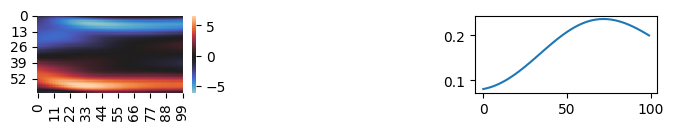

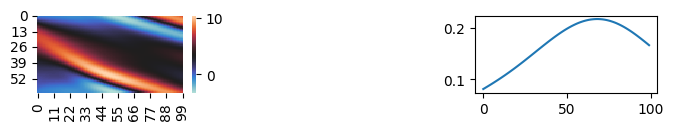

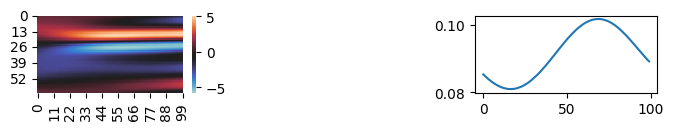

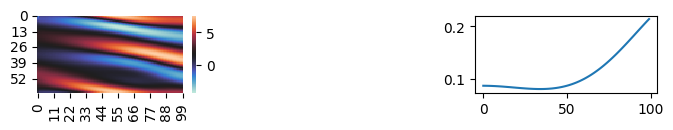

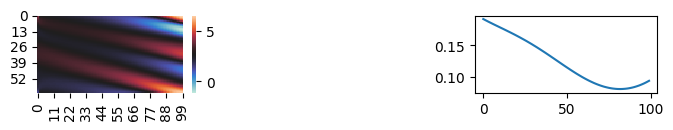

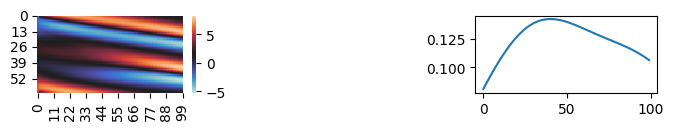

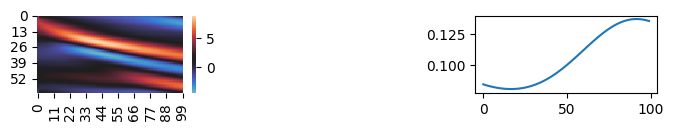

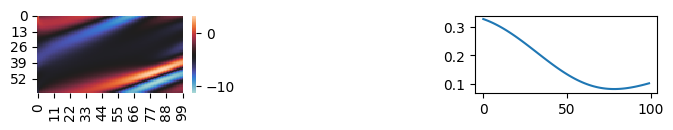

In [3]:
ind = 10
for ind in range(10):
    s = Xs[ind]
    fig = plt.figure(figsize=(8,1))
    ax0 = fig.add_subplot(1,3,1)
    data = pd.DataFrame(Xs[ind,:,:])
    data.replace(0, np.nan, inplace=True)
    cmap = sns.heatmap(data,center=s.mean())
    
    #ax1 = fig.add_subplot(1,3,2)
    #plt.plot(Xs[ind,0])
    
    ax2 = fig.add_subplot(1,3,3)
    plt.plot(us[ind])


In [ ]:
us = reader.read_field('us')
print(us.shape)